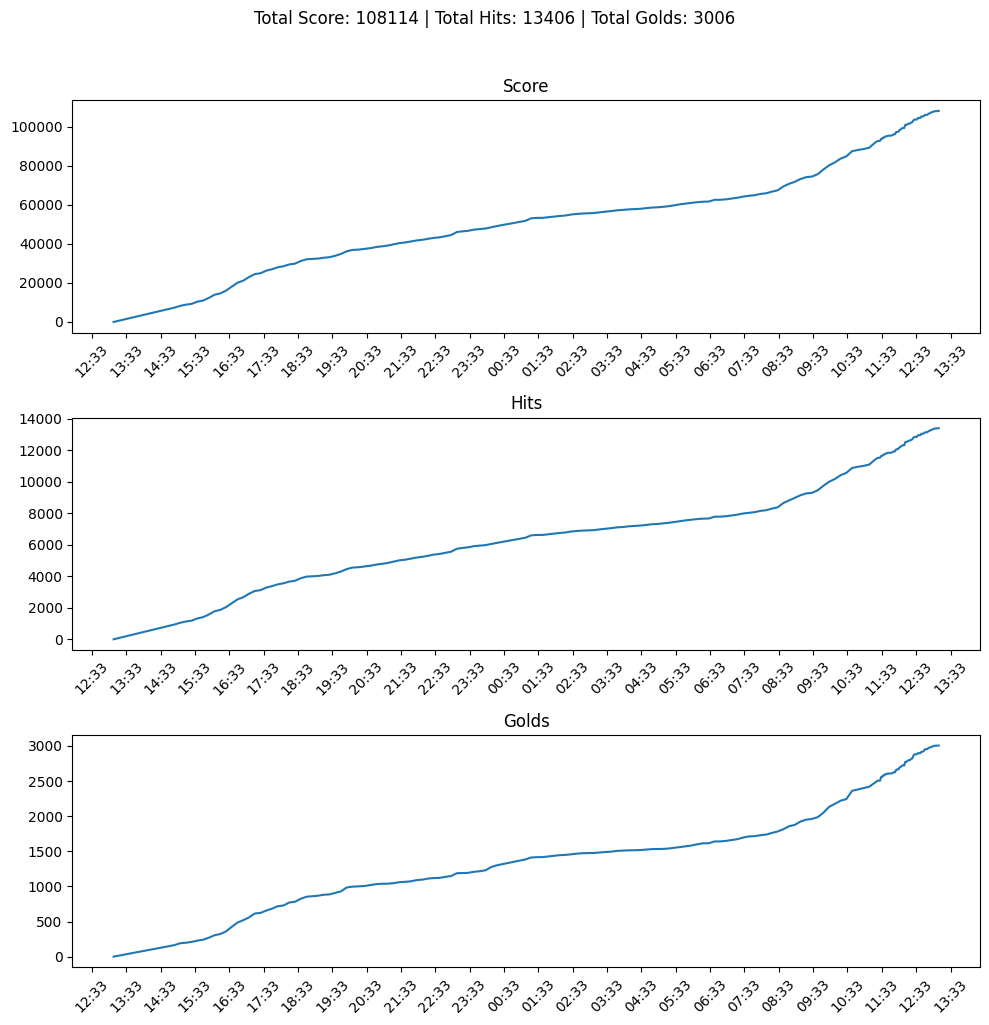

In [35]:
from matplotlib import pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

scoreData = pd.read_csv("brit_results.csv")

scoreData['timestamp_utc'] = pd.to_datetime(scoreData['timestamp_utc'], errors='coerce')
#scoreData['time'] = scoreData['timestamp_utc'].dt.floor('min')
#scoreData['time'] = scoreData['time'].dt.time

fig, ax = plt.subplots(nrows=3, figsize=(10, 10))
ax[0].plot(scoreData['timestamp_utc'], scoreData['score_total'])
ax[1].plot(scoreData['timestamp_utc'], scoreData['hits_total'])
ax[2].plot(scoreData['timestamp_utc'], scoreData['golds_total'])
ax[0].set_title("Score")
ax[1].set_title("Hits")
ax[2].set_title("Golds")

for i in range(3):
    ax[i].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax[i].xaxis.set_major_locator(mdates.MinuteLocator(interval=60))
    ax[i].tick_params(axis='x', rotation=45)
    
plt.suptitle(f'Total Score: {scoreData["score_total"].max() :.0f} | Total Hits: {scoreData["hits_total"].max():.0f} | Total Golds: {scoreData["golds_total"].max():.0f}', y=1.02)
plt.tight_layout()

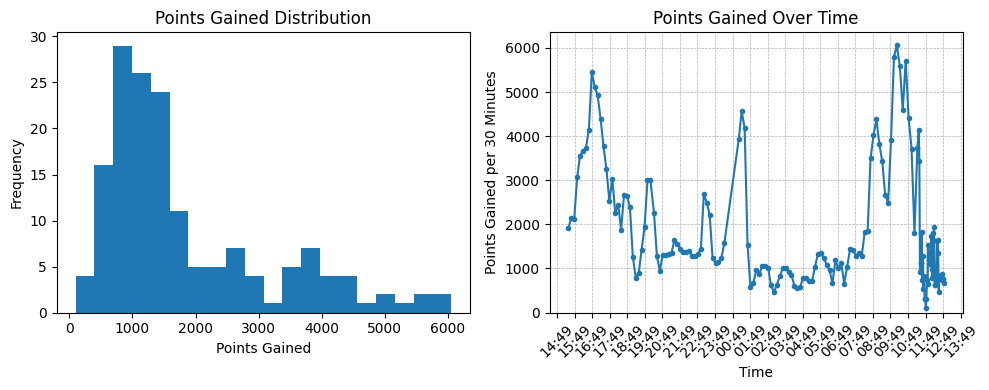

In [136]:
import numpy as np
scoreData['pointsGained'] = scoreData['score_total'].diff().fillna(np.nan)

#score gained every 30 mins - 3 rows

scoreData['pointsGained30min'] = scoreData['score_total'].diff(periods=3).fillna(np.nan)

figPG, axPG = plt.subplots(ncols = 2, figsize=(10, 4))
axPG[0].hist(scoreData['pointsGained30min'].dropna(), bins = 20)
axPG[1].plot(scoreData['timestamp_utc'], scoreData['pointsGained30min'], marker='.')

axPG[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

axPG[0].set_title("Points Gained Distribution")
axPG[1].set_title("Points Gained Over Time")

axPG[0].set_xlabel("Points Gained")
axPG[0].set_ylabel("Frequency")

axPG[1].set_xlabel("Time")
axPG[1].set_ylabel("Points Gained per 30 Minutes")

axPG[1].xaxis.set_major_locator(mdates.MinuteLocator(interval=60))
axPG[1].tick_params(axis='x', rotation=45)
axPG[1].set_ylim(bottom=0)
axPG[1].grid(True, which='both', linestyle='--', linewidth=0.5)
#
# axPG[1].set_xticks(ticks = scoreData['timestamp_utc'] ,rotation=45)
figPG.tight_layout()

In [132]:
scoreData['pointsGained30min'].mean(skipna=True)*2*24

np.float64(93687.48936170213)

In [37]:
from datetime import datetime
import time
timeNow = datetime.now()

timeHoursMins = timeNow.strftime("%H:%M")

timeLastRecorded = scoreData['timestamp_utc'].iloc[-1].strftime("%H:%M")

hoursLeft = 13 - int(timeHoursMins.split(":")[0]) -1
minutesLeft = 60 - int(timeHoursMins.split(":")[1])

reqPointsPerMin = (100000 - scoreData['score_total'].max()) / (hoursLeft*60 + minutesLeft)

reqPointsPer30Mins = reqPointsPerMin*30

reqPointsPer30Mins

np.float64(2932.7710843373497)

In [38]:
scoreData.drop_duplicates(subset=['score_total'], keep='first', inplace=True)
try:
    scoreData.drop(columns=['rows_scraped'], inplace=True)
except:
    pass
scoreData['decimalTime'] = scoreData['timestamp_utc'].dt.hour + scoreData['timestamp_utc'].dt.minute / 60

# round and make finish at 13:00 exactly 
scoreData['decimalTime'] = scoreData['decimalTime'] - (scoreData['decimalTime'].iloc[-1]-13)
scoreData['decimalTime'] = scoreData['decimalTime'].round(2)

#map so that 13:00 is 00:00
scoreData['decimalTime'] = scoreData['decimalTime'].apply(lambda x: x + 11 if x <= 13 else x - 13)

def scoreOverTime(time):
    '''time in format str of HH.XX where XX = MM/60'''
    return np.interp(time, scoreData['decimalTime'], scoreData['score_total'])

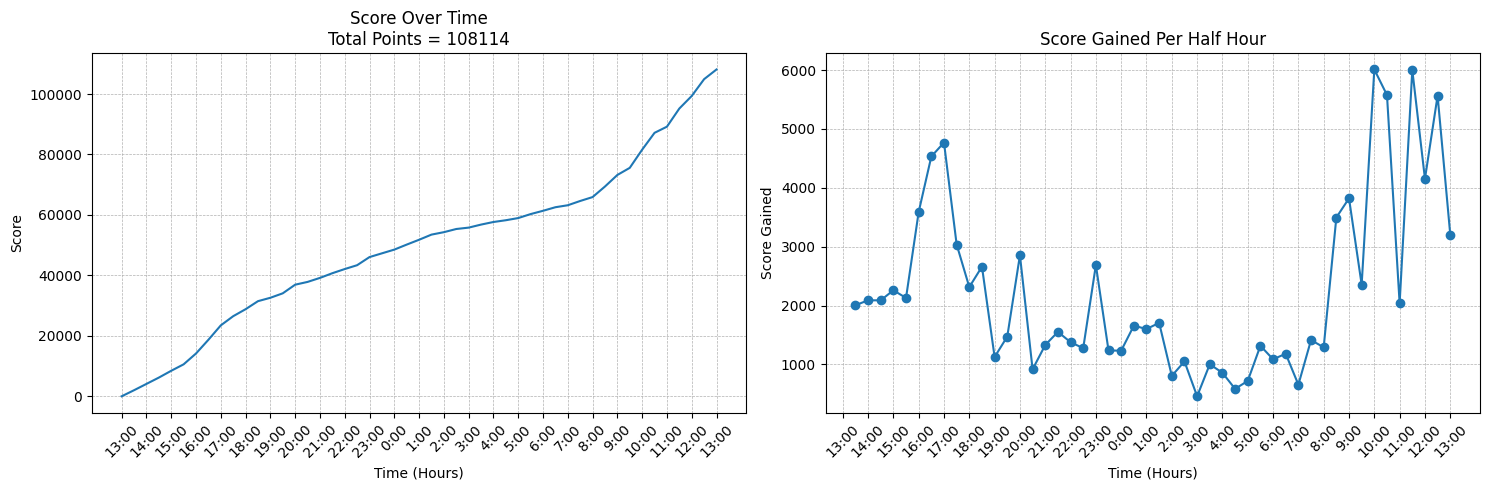

In [61]:
import numpy as np

oneHourIntervals = np.arange(0, 24.1, 1)
thirtyMinIntervals = np.arange(0, 24.1, 0.5)

scoresAtIntervals = scoreOverTime(thirtyMinIntervals)
scoreGainedPerHour = np.diff(scoresAtIntervals)

hourLabels = np.hstack((np.arange(13, 23.1, 1), np.arange(0, 13.1, 1)))

fig, ax = plt.subplots(ncols = 2, figsize=(15, 5))
ax[0].plot(thirtyMinIntervals, scoresAtIntervals)
ax[0].set_title(f"Score Over Time\nTotal Points = {scoreData['score_total'].max():.0f}")
ax[0].set_xlabel("Time (Hours)")
ax[0].set_ylabel("Score")
#ax.set_xticklabels([f"{int(hour+1)%12 if int(hour)%12 != 0 else 12}:{'00' if hour%1 == 0 else '30'} {'AM' if hour < 12 else 'PM'}" for hour in oneHourIntervals], rotation=45)
ax[0].set_xticks(thirtyMinIntervals[::2])
ax[0].set_xticklabels([f'{int(hour)}:00' for hour in hourLabels], rotation=45)
ax[0].grid(True, which='both', linestyle='--', linewidth=0.5)

ax[1].plot(thirtyMinIntervals[1:], scoreGainedPerHour, marker='o')
ax[1].set_title("Score Gained Per Half Hour")
ax[1].set_xlabel("Time (Hours)")
ax[1].set_ylabel("Score Gained")
ax[1].grid(True, which='both', linestyle='--', linewidth=0.5)
ax[1].set_xticks(thirtyMinIntervals[::2])
ax[1].set_xticklabels([f'{int(hour)}:00' for hour in hourLabels], rotation=45)
plt.tight_layout()